In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns

In [2]:
df_cars=pd.read_csv("cleaned_data.csv")

In [4]:
df_acsm=df_cars[["make","condition","sellingprice","vehicle_age"]]


In [5]:
df_acsm.shape

(558598, 4)

In [6]:
pd.options.display.float_format = "{:.3f}".format

In [7]:
top_fifteen=df_cars["make"].value_counts()[0:15]

In [8]:
t_fifteen_make=pd.DataFrame(top_fifteen).reset_index()["make"]

In [13]:
plot_df = (
    df_cars
    .groupby(["make", "vehicle_age"], as_index=False)[["condition","sellingprice"]]
    .mean()
)

In [14]:
plot_df=plot_df[plot_df["make"].isin(t_fifteen_make)]

In [15]:
filreted_grp=[]
grp=plot_df.groupby('make')
for make,df in grp:
    std=df['condition'].std()
    avg=df['condition'].mean()
    df=df[(df['condition']>avg-3*std)&(df['condition']<avg+3*std)]
    df["make"]=make
    filreted_grp.append(df)
pd.concat(filreted_grp, ignore_index=True)

C:\Users\ojasv\AppData\Local\Temp\ipykernel_31348\537925714.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["make"]=make


,make,vehicle_age,condition,sellingprice
0,Bmw,0.119,36.647,39029.412
1,Bmw,0.124,5.000,64000.000
2,Bmw,0.138,5.000,27600.000
3,Bmw,0.146,24.000,30000.000
4,Bmw,0.157,34.393,36305.357
...,...,...,...,...
21904,Volkswagen,18.255,22.000,800.000
21905,Volkswagen,18.264,2.000,450.000
21906,Volkswagen,19.100,2.000,375.000
21907,Volkswagen,19.122,2.000,350.000


<Axes: >

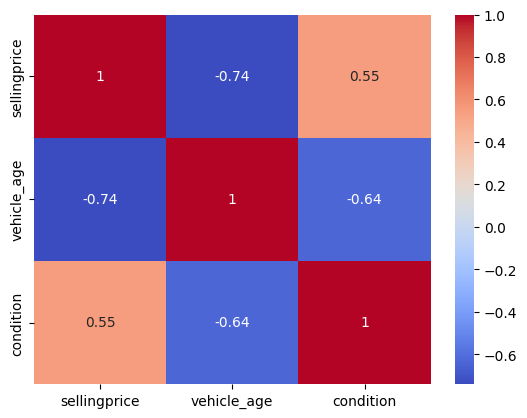

In [17]:
cols = ["sellingprice","vehicle_age","condition"]
sns.heatmap(plot_df[cols].corr(), annot=True, cmap="coolwarm")